# Hyperparameter tuning and over/underfitting analysis

Objectif de ce notebook :
1. tester plusieurs hyperparamètres avec cross-validation ;
2. sélectionner les meilleurs paramètres ;
3. comparer train/test pour détecter overfitting ou underfitting ;
4. générer 2-3 graphes directement utilisables dans le rapport.

Ce notebook reprend le même preprocessing que le notebook `modele.ipynb`.

In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

# Dossier pour sauvegarder les figures du rapport
os.makedirs("figures_tuning", exist_ok=True)

In [2]:
# =========================================================
# 1. CHARGEMENT DES DONNEES
# =========================================================

DATA_PATH = r"student_dataset/student_failure/train.csv"

df = pd.read_csv(DATA_PATH)
print("Shape raw dataset:", df.shape)
df.head()

Shape raw dataset: (630000, 15)


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


In [3]:
# =========================================================
# 2. PREPROCESSING IDENTIQUE AU NOTEBOOK MODELE
# =========================================================

df_ml = df.copy()

# Suppression de l'id
if "id" in df_ml.columns:
    df_ml = df_ml.drop(columns=["id"])

# Suppression des doublons
n_before = len(df_ml)
df_ml = df_ml.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(df_ml)}")

# Gestion des valeurs manquantes
num_cols = df_ml.select_dtypes(include=np.number).columns
cat_cols = df_ml.select_dtypes(include="object").columns

df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())
df_ml[cat_cols] = df_ml[cat_cols].fillna("unknown")

# Encodage binaire
if "genre" in df_ml.columns:
    df_ml["genre"] = df_ml["genre"].map({"male": 0, "female": 1}).fillna(0)

if "accès_internet" in df_ml.columns:
    df_ml["accès_internet"] = df_ml["accès_internet"].map({"yes": 1, "no": 0}).fillna(0)

# Encodage ordinal
if "qualité_sommeil" in df_ml.columns:
    df_ml["qualité_sommeil"] = df_ml["qualité_sommeil"].map({
        "poor": 0,
        "average": 1,
        "good": 2,
        "excellent": 3
    }).fillna(1)

if "évaluation_établissement" in df_ml.columns:
    df_ml["évaluation_établissement"] = df_ml["évaluation_établissement"].map({
        "low": 0,
        "medium": 1,
        "high": 2
    }).fillna(1)

if "difficulté_examen" in df_ml.columns:
    df_ml["difficulté_examen"] = df_ml["difficulté_examen"].map({
        "easy": 0,
        "moderate": 1,
        "hard": 2
    }).fillna(1)

# One-hot encoding
nominal_cols = [col for col in ["diplôme", "méthode_etude"] if col in df_ml.columns]
df_ml = pd.get_dummies(df_ml, columns=nominal_cols, drop_first=True)

# Conversion bool -> float
df_ml = df_ml.astype(float)

print("Shape after preprocessing:", df_ml.shape)
df_ml.head()

Doublons supprimés : 0


C:\Users\louis\AppData\Local\Temp\ipykernel_10780\642246179.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_ml.select_dtypes(include="object").columns


Shape after preprocessing: (630000, 23)


,age,genre,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,évaluation_établissement,difficulté_examen,score_examen,...,diplôme_Business Management,diplôme_Computer Science,diplôme_Engineering,diplôme_Law,diplôme_Marketing,méthode_etude_group study,méthode_etude_mixed,méthode_etude_online videos,méthode_etude_self-study,méthode_etude_unknown
0,21.0,0.0,7.91,98.8,0.0,4.9,1.0,0.0,0.0,75.02,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18.0,1.0,4.95,94.8,1.0,4.7,0.0,1.0,1.0,49.03,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,20.0,1.0,4.68,92.6,0.0,5.8,0.0,2.0,1.0,100.00,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,19.0,0.0,2.00,49.5,1.0,8.3,1.0,2.0,1.0,63.90,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,23.0,1.0,7.65,86.9,1.0,9.6,2.0,2.0,0.0,100.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
# =========================================================
# 3. SELECTION DES FEATURES
# =========================================================

selected_features = [
    "heures_etude",
    "genre",
    "assiduité_classe",
    "heures_sommeil",
    "qualité_sommeil",
    "évaluation_établissement",
    "accès_internet",
    "diplôme_Engineering",
    "diplôme_Marketing",
    "diplôme_Computer Science"
]

selected_features = [col for col in selected_features if col in df_ml.columns]

X = df_ml[selected_features]
y = df_ml["score_examen"]

print("Features utilisées:")
print(X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features utilisées:
['heures_etude', 'genre', 'assiduité_classe', 'heures_sommeil', 'qualité_sommeil', 'évaluation_établissement', 'accès_internet', 'diplôme_Engineering', 'diplôme_Marketing', 'diplôme_Computer Science']
X shape: (630000, 10)
y shape: (630000,)


In [5]:
# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (504000, 10)
Test size: (126000, 10)


## 1. Hyperparameter tuning avec cross-validation

Pour éviter un tuning trop lourd sur un PC portable, le tuning peut être fait sur un sous-échantillon du train set.  
Ensuite, le meilleur modèle est réentraîné sur tout le train set.

In [6]:
# =========================================================
# 5. SOUS-ECHANTILLON POUR LE TUNING
# =========================================================

# Ajuster cette valeur selon la puissance du PC.
# 50_000 ou 80_000 est souvent suffisant pour montrer la méthode sans bloquer le PC.
TUNING_SAMPLE_SIZE = 80_000

if len(X_train) > TUNING_SAMPLE_SIZE:
    X_tune = X_train.sample(TUNING_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_tune = y_train.loc[X_tune.index]
else:
    X_tune = X_train.copy()
    y_tune = y_train.copy()

print("Tuning sample size:", X_tune.shape)

Tuning sample size: (80000, 10)


In [7]:
# =========================================================
# 6. GRID SEARCH CV
# =========================================================

# Ridge est mis dans un pipeline avec StandardScaler car il est sensible à l'échelle des variables.
# Les arbres et Random Forest n'ont pas besoin de scaling.

models_params = {
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "params": {
            "max_depth": [3, 5, 10, 15, None],
            "min_samples_leaf": [1, 5, 10, 20],
            "max_leaf_nodes": [20, 50, 100, 200]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [5, 10, 15, None],
            "min_samples_leaf": [1, 5, 10]
        }
    },

    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge())
        ]),
        "params": {
            "ridge__alpha": [0.01, 0.1, 1, 10, 100]
        }
    }
}

best_models = {}
tuning_rows = []

for name, mp in models_params.items():
    print(f"\n===== TUNING: {name} =====")

    grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_tune, y_tune)

    print("Best parameters:", grid.best_params_)
    print("Best CV RMSE:", -grid.best_score_)

    # Réentraînement du meilleur modèle sur tout le train set
    best_model = grid.best_estimator_
    best_model.fit(X_train, y_train)

    best_models[name] = best_model

    tuning_rows.append({
        "Model": name,
        "Best parameters": grid.best_params_,
        "Best CV RMSE": -grid.best_score_
    })

tuning_df = pd.DataFrame(tuning_rows)
tuning_df


===== TUNING: Decision Tree =====
Best parameters: {'max_depth': 10, 'max_leaf_nodes': 200, 'min_samples_leaf': 20}
Best CV RMSE: 10.579525846116892

===== TUNING: Random Forest =====
Best parameters: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV RMSE: 9.980744917424694

===== TUNING: Ridge Regression =====
Best parameters: {'ridge__alpha': 1}
Best CV RMSE: 9.860175986940703


,Model,Best parameters,Best CV RMSE
0,Decision Tree,"{'max_depth': 10, 'max_leaf_nodes': 200, 'min_...",10.579526
1,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 10, 'n_e...",9.980745
2,Ridge Regression,{'ridge__alpha': 1},9.860176


## 2. Résultats train/test pour détecter overfitting ou underfitting

Principe :
- **overfitting** : erreur train faible, erreur test nettement plus élevée ;
- **underfitting** : erreurs train et test toutes les deux élevées ;
- **bonne généralisation** : erreurs train/test proches et erreur test faible.

In [8]:
# =========================================================
# 7. TRAIN / TEST METRICS
# =========================================================

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results_rows = []

# Baseline : moyenne du train
baseline_train_pred = np.full(len(y_train), y_train.mean())
baseline_test_pred = np.full(len(y_test), y_train.mean())

baseline_train_metrics = compute_metrics(y_train, baseline_train_pred)
baseline_test_metrics = compute_metrics(y_test, baseline_test_pred)

results_rows.append({
    "Model": "Baseline",
    "Train MAE": baseline_train_metrics["MAE"],
    "Test MAE": baseline_test_metrics["MAE"],
    "Train RMSE": baseline_train_metrics["RMSE"],
    "Test RMSE": baseline_test_metrics["RMSE"],
    "Train R2": baseline_train_metrics["R2"],
    "Test R2": baseline_test_metrics["R2"],
    "RMSE gap": baseline_test_metrics["RMSE"] - baseline_train_metrics["RMSE"]
})

for name, model in best_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_metrics = compute_metrics(y_train, y_train_pred)
    test_metrics = compute_metrics(y_test, y_test_pred)

    results_rows.append({
        "Model": name,
        "Train MAE": train_metrics["MAE"],
        "Test MAE": test_metrics["MAE"],
        "Train RMSE": train_metrics["RMSE"],
        "Test RMSE": test_metrics["RMSE"],
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"],
        "RMSE gap": test_metrics["RMSE"] - train_metrics["RMSE"]
    })

results_df = pd.DataFrame(results_rows)
results_df = results_df.sort_values("Test RMSE")
results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,RMSE gap
3,Ridge Regression,7.825802,7.812564,9.831041,9.828107,0.731261,0.729508,-0.002934
2,Random Forest,7.829136,7.922237,9.825865,9.949805,0.731544,0.722767,0.123940
1,Decision Tree,8.296612,8.338389,10.394832,10.446864,0.699554,0.694376,0.052032
0,Baseline,15.606206,15.545894,18.964183,18.897375,0.000000,-0.000042,-0.066808


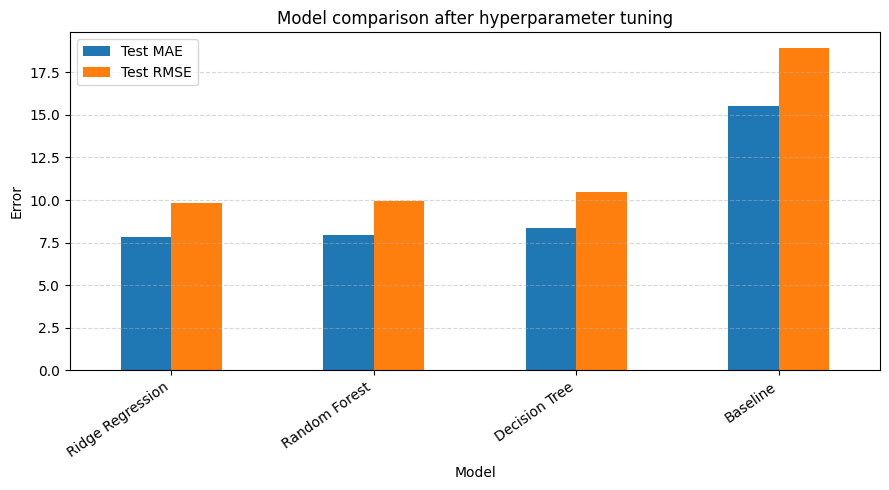

In [9]:
# =========================================================
# FIGURE 1 : COMPARAISON DES MODELES APRES TUNING
# =========================================================

plot_df = results_df.set_index("Model")[["Test MAE", "Test RMSE"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Model comparison after hyperparameter tuning")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("figures_tuning/01_model_comparison_after_tuning.png", dpi=300)
plt.show()

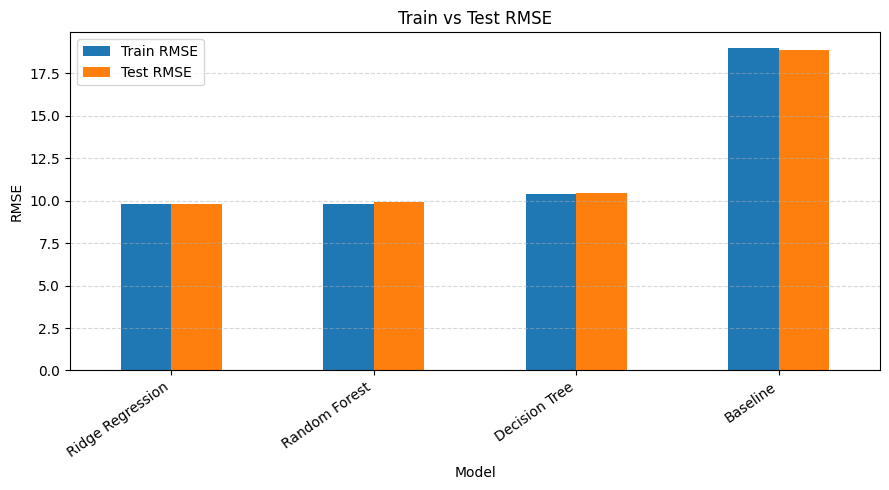

In [10]:
# =========================================================
# FIGURE 2 : TRAIN VS TEST RMSE
# =========================================================

plot_df = results_df.set_index("Model")[["Train RMSE", "Test RMSE"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Train vs Test RMSE")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("figures_tuning/02_train_vs_test_rmse.png", dpi=300)
plt.show()

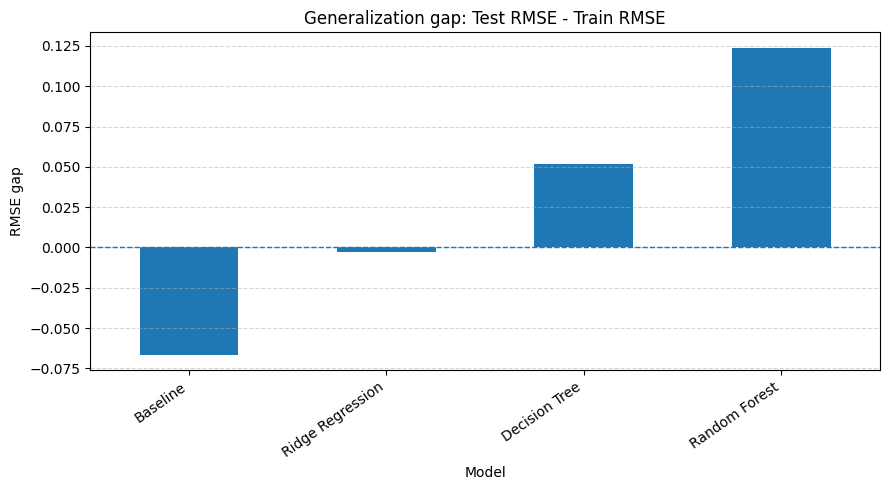

In [11]:
# =========================================================
# FIGURE 3 : RMSE GAP
# =========================================================

gap_df = results_df.set_index("Model")["RMSE gap"].sort_values()

ax = gap_df.plot(kind="bar", figsize=(9, 5))
plt.title("Generalization gap: Test RMSE - Train RMSE")
plt.ylabel("RMSE gap")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.axhline(0, linestyle="--", linewidth=1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("figures_tuning/03_generalization_gap.png", dpi=300)
plt.show()

## 3. Learning curve du meilleur modèle

La learning curve permet de voir si le modèle manque de données, overfit ou underfit.

Interprétation :
- train score très bon mais validation score moins bon → overfitting ;
- train et validation mauvais → underfitting ;
- train et validation proches avec bonne performance → bonne généralisation.

Best model for learning curve: Ridge Regression


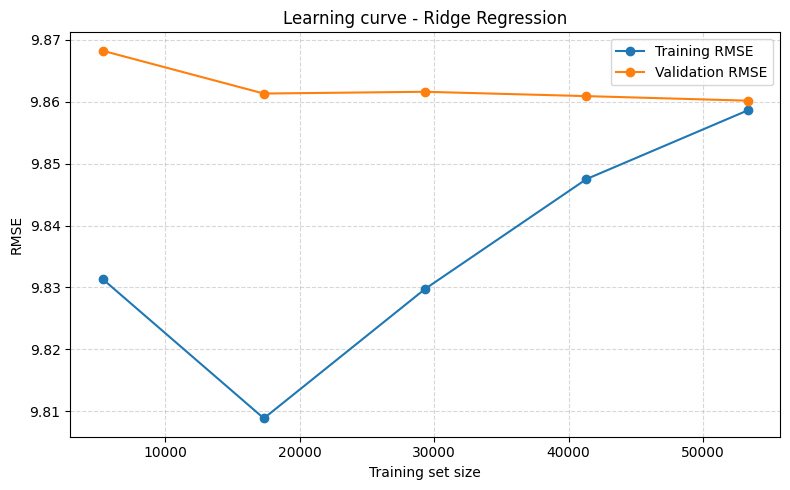

In [12]:
# =========================================================
# FIGURE 4 : LEARNING CURVE DU MEILLEUR MODELE
# =========================================================

best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Baseline":
    # Si jamais la baseline est première, on prend le meilleur vrai modèle
    best_model_name = results_df[results_df["Model"] != "Baseline"].iloc[0]["Model"]

best_model = best_models[best_model_name]

print("Best model for learning curve:", best_model_name)

# Pour ne pas exploser le temps de calcul
LC_SAMPLE_SIZE = 80_000

if len(X_train) > LC_SAMPLE_SIZE:
    X_lc = X_train.sample(LC_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_lc = y_train.loc[X_lc.index]
else:
    X_lc = X_train.copy()
    y_lc = y_train.copy()

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_lc,
    y=y_lc,
    cv=3,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation RMSE")
plt.title(f"Learning curve - {best_model_name}")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("figures_tuning/04_learning_curve_best_model.png", dpi=300)
plt.show()

## 4. Texte directement réutilisable dans le rapport

In [13]:
# =========================================================
# 8. GENERATION D'UN RESUME TEXTUEL POUR LE RAPPORT
# =========================================================

best_row = results_df.iloc[0]
best_model_name = best_row["Model"]

report_text = (
    "Hyperparameter tuning was performed using GridSearchCV with 3-fold cross-validation. "
    "The selection criterion was the validation RMSE, because RMSE penalizes large prediction errors. "
    "For each model, the best hyperparameters were selected on the training data and the final model "
    "was then evaluated on the independent test set.\n\n"
    f"The best model after tuning was {best_model_name}, with a test RMSE of {best_row['Test RMSE']:.2f}, "
    f"a test MAE of {best_row['Test MAE']:.2f}, and a test R² of {best_row['Test R2']:.3f}.\n\n"
    "Overfitting and underfitting were analysed by comparing training and test performances. "
    "A large difference between train and test RMSE indicates overfitting, while high errors on both "
    "training and test sets indicate underfitting. The RMSE gap was therefore used as an indicator "
    "of generalization. The final selected model shows a limited train-test gap compared with more "
    "complex models, indicating better generalization on unseen data."
)

print(report_text)

Hyperparameter tuning was performed using GridSearchCV with 3-fold cross-validation. The selection criterion was the validation RMSE, because RMSE penalizes large prediction errors. For each model, the best hyperparameters were selected on the training data and the final model was then evaluated on the independent test set.

The best model after tuning was Ridge Regression, with a test RMSE of 9.83, a test MAE of 7.81, and a test R² of 0.730.

Overfitting and underfitting were analysed by comparing training and test performances. A large difference between train and test RMSE indicates overfitting, while high errors on both training and test sets indicate underfitting. The RMSE gap was therefore used as an indicator of generalization. The final selected model shows a limited train-test gap compared with more complex models, indicating better generalization on unseen data.
